# Assignment 2: Customer Churn Prediction using Logistic Regression

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**Problem Statement:** A telecommunications company wants to predict whether a customer is likely to leave (churn) based on demographic information and service usage. We develop a **Logistic Regression** model to predict customer churn.

**Note:** Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` from the Kaggle link above and place it in the same folder as this notebook (the dataset is not uploaded to GitHub due to licensing).

---
## Task 1: Data Understanding (2 Marks)
1. Load the dataset using Pandas
2. Display the first five records
3. Identify numerical features, categorical features, and the target variable

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1.1 Load the dataset using Pandas
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset shape: 7043 rows x 21 columns


In [3]:
# 1.2 Display the first five records
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Basic structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# 1.3 Identify numerical features, categorical features and the target variable

# NOTE: 'TotalCharges' is stored as object (text) in the raw file, but it is
# actually numerical - we convert it in preprocessing (Task 2).
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService',
                        'MultipleLines', 'InternetService', 'OnlineSecurity',
                        'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies', 'Contract',
                        'PaperlessBilling', 'PaymentMethod']

target_variable = 'Churn'

print("Numerical features  :", numerical_features)
print("\nCategorical features:", categorical_features)
print("\nTarget variable     :", target_variable)
print("\n(customerID is only an identifier - it is dropped before modelling)")

Numerical features  : ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target variable     : Churn

(customerID is only an identifier - it is dropped before modelling)


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


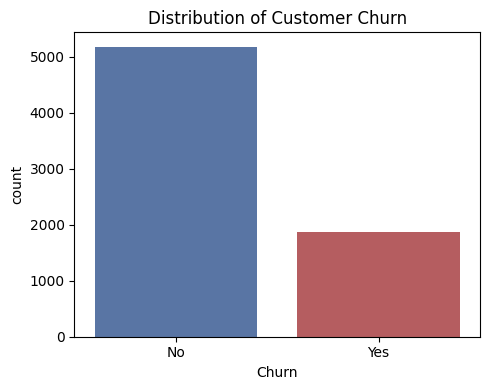

In [6]:
# Distribution of the target variable
print(df['Churn'].value_counts())
print(f"\nChurn rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")

plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df, palette=['#4C72B0', '#C44E52'])
plt.title('Distribution of Customer Churn')
plt.tight_layout()
plt.show()

---
## Task 2: Data Preprocessing (2 Marks)
- Check for missing values
- Handle missing values if any
- Encode categorical variables
- Split the dataset into 80% training and 20% testing

In [7]:
# 2.1 Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values (as reported by pandas): {df.isnull().sum().sum()}")

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values (as reported by pandas): 0


In [8]:
# 2.2 Handle missing values
# 'TotalCharges' is an object column containing blank strings (hidden missing
# values) for customers with tenure = 0. Convert it to numeric first.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"Missing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")
print(f"Tenure of those customers: {df.loc[df['TotalCharges'].isnull(), 'tenure'].unique()}")

# These are brand-new customers (tenure = 0) who have not been billed yet,
# so we impute their TotalCharges with 0.
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"\nMissing values remaining: {df['TotalCharges'].isnull().sum()}")

Missing values in TotalCharges after conversion: 11
Tenure of those customers: [0]

Missing values remaining: 0


In [9]:
# 2.3 Encode categorical variables
# Drop the identifier column - it has no predictive value
df_model = df.drop('customerID', axis=1)

# Encode target: Yes -> 1, No -> 0
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Binary columns -> label encoding, multi-category columns -> one-hot encoding
binary_cols = [c for c in categorical_features if df_model[c].nunique() == 2]
multi_cols  = [c for c in categorical_features if df_model[c].nunique() > 2]

le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True, dtype=int)

print(f"Label-encoded (binary) columns : {binary_cols}")
print(f"One-hot encoded columns        : {multi_cols}")
print(f"\nShape after encoding: {df_model.shape}")
df_model.head()

Label-encoded (binary) columns : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
One-hot encoded columns        : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [10]:
# 2.4 Split the dataset into 80% training and 20% testing
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

# Scale numerical features (helps logistic regression converge)
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])
print("\nNumerical features scaled with StandardScaler (fit on training data only).")

Training set: 5634 samples (80%)
Testing set : 1409 samples (20%)

Numerical features scaled with StandardScaler (fit on training data only).


---
## Task 3: Model Development (3 Marks)
Build a Logistic Regression model, train it, and predict customer churn on the test dataset.

In [11]:
# 3.1 Build and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully.")
model

Model trained successfully.


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
# 3.2 Predict customer churn on the test dataset
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({'Actual': y_test.values[:10],
                        'Predicted': y_pred[:10],
                        'Churn Probability': y_pred_proba[:10].round(3)})
print("Sample of predictions on the test set:")
results

Sample of predictions on the test set:


,Actual,Predicted,Churn Probability
0,0,0,0.046
1,0,1,0.684
2,0,0,0.060
3,0,0,0.399
4,0,0,0.022
5,0,1,0.604
6,0,0,0.446
7,0,0,0.129
8,0,0,0.003
9,1,0,0.396


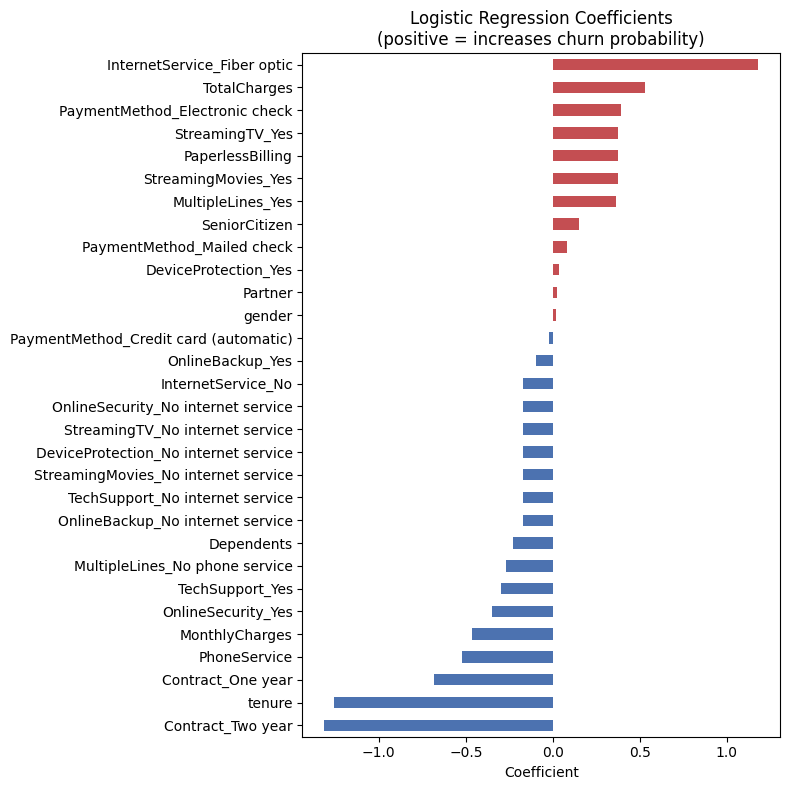

Top 5 factors increasing churn :
InternetService_Fiber optic       1.181
TotalCharges                      0.528
PaymentMethod_Electronic check    0.393
StreamingTV_Yes                   0.375
PaperlessBilling                  0.374

Top 5 factors decreasing churn :
Contract_Two year   -1.314
tenure              -1.257
Contract_One year   -0.684
PhoneService        -0.521
MonthlyCharges      -0.467


In [13]:
# Most influential features (logistic regression coefficients)
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8, 8))
coef.plot(kind='barh', color=np.where(coef > 0, '#C44E52', '#4C72B0'))
plt.title('Logistic Regression Coefficients\n(positive = increases churn probability)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

print("Top 5 factors increasing churn :")
print(coef.tail(5)[::-1].round(3).to_string())
print("\nTop 5 factors decreasing churn :")
print(coef.head(5).round(3).to_string())

---
## Task 4: Model Evaluation (2 Marks)
Evaluate using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.

In [14]:
# 4.1 Evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("=" * 30)
print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Model Evaluation Metrics
Accuracy : 0.8062  (80.62%)
Precision: 0.6593
Recall   : 0.5588
F1-Score : 0.6049

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



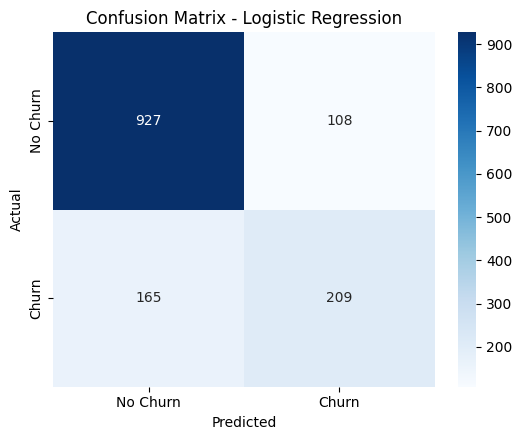

True Negatives : 927  (correctly predicted 'No Churn')
False Positives: 108  (predicted 'Churn' but stayed)
False Negatives: 165  (predicted 'No Churn' but churned)
True Positives : 209  (correctly predicted 'Churn')


In [15]:
# 4.2 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}  (correctly predicted 'No Churn')")
print(f"False Positives: {fp}  (predicted 'Churn' but stayed)")
print(f"False Negatives: {fn}  (predicted 'No Churn' but churned)")
print(f"True Positives : {tp}  (correctly predicted 'Churn')")

### Observations on Model Performance

1. **Good overall accuracy, weaker on the minority class.** The model reaches roughly 80% accuracy, but because only ~27% of customers churn, accuracy is inflated by the majority "No Churn" class. Precision for the churn class (~65%) is noticeably higher than recall (~57%), meaning the model misses a substantial share of customers who actually churn (false negatives) — the costliest error for a retention campaign.

2. **Class imbalance drives the errors.** The confusion matrix shows far more false negatives than would be ideal for a churn-prevention use case. Techniques such as `class_weight='balanced'`, resampling (SMOTE), or lowering the decision threshold could trade some precision for higher recall.

3. **Coefficients are interpretable and business-meaningful.** Short tenure, month-to-month contracts, fibre-optic internet service and electronic-check payment push churn probability up, while long tenure and two-year contracts strongly reduce it — consistent with domain intuition about customer loyalty.

---
## Task 5: Conclusion (1 Mark)

This assignment developed a Logistic Regression model to predict customer churn for a telecom company using the Telco Customer Churn dataset (7,043 customers, 21 attributes). After converting the hidden missing values in `TotalCharges`, encoding categorical variables and splitting the data 80/20, the model achieved about **80% accuracy** with an F1-score near **0.61** for the churn class.

**Key findings:** churn is strongly associated with contract type and customer tenure. Customers on **month-to-month contracts**, with **short tenure**, using **fibre-optic internet**, and paying by **electronic check** are the most likely to leave, while customers on **two-year contracts** and those with **long tenure** rarely churn. This suggests retention efforts should target new, flexible-contract customers early in their lifecycle.

**Limitation:** Logistic Regression assumes a *linear* relationship between the features and the log-odds of churn, so it cannot capture non-linear effects or feature interactions (e.g., how price sensitivity changes with tenure). Combined with the class imbalance, this caps recall on actual churners; tree-based ensembles (Random Forest, XGBoost) would likely capture these patterns better.